In [1]:
import pandas as pd

In [15]:
truth=pd.read_csv('/Users/rm026/Documents/msa/msa_local_filelist_w_baseline_info.csv')
results=pd.read_csv('/Users/rm026/Documents/code/reviewpyper_testing/tests/bars_severity_gpt4_from_arun/bars_severity_master_list.csv')
merged=pd.merge(results,truth,left_on='MRN',right_on='fake_mrn',how='inner')
merged=merged.dropna(subset=['BARS'])
merged=merged.sort_values(by='MRN_x').reset_index(drop=True)
# merged=merged.drop(['0','3','5','6'], axis=0)
merged=merged.drop([0,3,5,6,8,13], axis=0)
merged

,MRN_x,filepath,gait,"EXPLANATION: For this patient, rate the severity of disturbed gait or walking difficulty (staggering, trouble turning, needs cane/wall, cannot walk unaided) on a 0–3 scale. 0=none/absent, 1=mild, 2=moderate, 3=severe. Return only a single integer between 0 and 3; if not mentioned, return 0.",heel-shin,"EXPLANATION: For this patient, rate the severity of difficulty performing heel–shin (jerky lowering or lateral movements) on a 0–3 scale. 0=none/absent, 1=mild, 2=moderate, 3=severe. Return only a single integer 0–3; if not mentioned, return 0.",dysarthria,"EXPLANATION: For this patient, rate the severity of dysarthria or slurred, partly unintelligible speech (not hypophonia) on a 0–3 scale. 0=none/absent, 1=mild, 2=moderate, 3=severe. Return only a single integer 0–3; if not mentioned, return 0.",oculomotor,"EXPLANATION: For this patient, rate the severity of oculomotor abnormalities (slowed pursuit, saccadic intrusions, hypo/hypermetric saccades, nystagmus) on a 0–3 scale. 0=none/absent, 1=mild, 2=moderate, 3=severe. Return only a single integer 0–3; if not mentioned, return 0.",...,BARS_negative,UPDRS_III_negative,dataset,subject,orig_roi_vol,roi_2mm,avgRFz,avgR,t,roi_2mm_smoothed
1,1,/Users/rm026/Documents/code/ReviewPyper_testin...,4.0,The patient is unable to perform the Timed Up ...,4.0,The report mentions that the patient lowers he...,3.5,The patient's speech is reported to be moderat...,3.0,The report mentions saccadic intrusions which ...,...,-29.5,NaN,msa,subhE15326460ucomposite,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...
2,2,/Users/rm026/Documents/code/ReviewPyper_testin...,3.0,The EMR report indicates that the patient has ...,2.0,The Heel-knee-shin test is noted in the report...,1.0,The patient's speech is noted for slight slurr...,1.0,The patient's oculomotor abnormalities are des...,...,-10.5,NaN,msa,subhE10011940ucomposite,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...
4,3,/Users/rm026/Documents/code/ReviewPyper_testin...,8.0,The patient has severe difficulty walking and ...,3.0,The patient's knee-tibia (heel-shin) test scor...,2.0,The patient's Dysarthria is mild as indicated ...,1.0,The patient has a score of 1 under oculomotor ...,...,-23.0,-17.0,msa,subhE42032160ucomposite,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...
7,4,/Users/rm026/Documents/code/ReviewPyper_testin...,3.0,The patient has severe walking difficulty; the...,3.0,The text reports marked abnormality in patient...,2.0,The patient has moderate dysarthria; report me...,1.0,The patient has mild oculomotor abnormalities;...,...,-20.5,NaN,msa,subhE19757590ucomposite,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm026/Partners HealthCare Dropbox/Ross ...
9,5,/Users/rm026/Documents/code/ReviewPyper_testin...,3.0,Gait: 1 is reported in multiple instances in t...,2.0,NaN,3.0,"Dysarthria 1 is clearly noted in the report, i...",1.0,Oculomotor abnormalities are mentioned with H ...,...,-9.0,NaN,msa,subhL1515950ucomposite,/Users/rm026/Partners HealthCare Dropbox/Ross ...,/Users/rm02

In [18]:
qs={'gait':8, 'heel-shin':4, 'finger-nose':4, 'dysarthria':4, 'oculomotor':2}
bars=[]
for question, weight in qs.items():
    # merged
    merged[f'{question}_weighted']=[value*weight/3 if value<=3 else 3*weight/3 for value in merged[question] ]
merged['estimated_bars']=merged['gait']+merged['heel-shin']+merged['finger-nose']+merged['dysarthria']+merged['oculomotor']
merged['estimated_bars']

1     18.5
2      9.0
4     17.0
7     11.0
9     10.0
10    11.0
11    15.0
12    11.0
14    13.5
15    11.0
16    13.0
17    16.0
18     9.0
Name: estimated_bars, dtype: float64

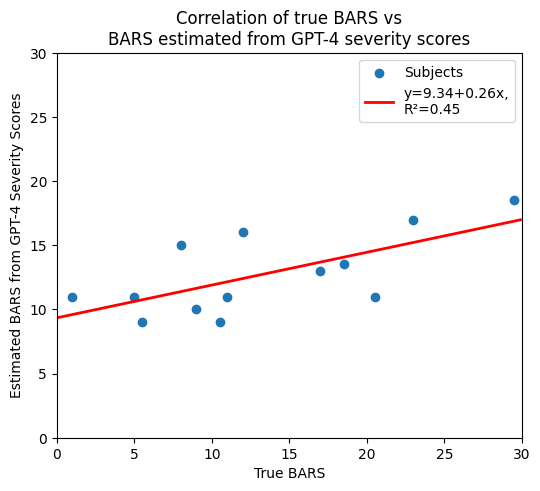

In [32]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(6, 5))


ax.scatter(merged['BARS'], merged['estimated_bars'])
plt.xlabel('True BARS')
plt.ylabel('Estimated BARS from GPT-4 Severity Scores')
plt.title('Correlation of true BARS vs\nBARS estimated from GPT-4 severity scores')
plt.ylim(0, 30)
plt.xlim(0, 30)
# Fit linear regression via least squares with numpy.polyfit
# It returns an slope (b) and intercept (a)
# deg=1 means linear fit (i.e. polynomial of degree 1)
b, a = np.polyfit(merged['BARS'], merged['estimated_bars'], deg=1)

# Create sequence of 100 numbers from 0 to 100
xseq = np.arange(0,30,.1 )

# Plot regression line
ax.plot(xseq, a + b * xseq, color='red', lw=2)
ax.legend(['Subjects',f'y={a:.2f}+{b:.2f}x,\nR²={np.corrcoef(merged["BARS"], merged["estimated_bars"])[0,1]**2:.2f}'])
plt.savefig('/Users/rm026/Documents/code/reviewpyper_testing/plots/bars_severity_correl_to_truth_plot.png', dpi=300)


In [29]:
import statsmodels.api as sm
model = sm.GLM(merged['BARS'], merged['estimated_bars'], family=sm.families.Gaussian())

results = model.fit()

print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   BARS   No. Observations:                   13
Model:                            GLM   Df Residuals:                       12
Model Family:                Gaussian   Df Model:                            0
Link Function:               Identity   Scale:                          41.139
Method:                          IRLS   Log-Likelihood:                -42.086
Date:                Wed, 05 Nov 2025   Deviance:                       493.67
Time:                        15:45:37   Pearson chi2:                     494.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4284
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
estimated_bars     1.0708      0.136      7.